In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("phishing_websites.csv")
data.head(10)

,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report,result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1
5,-1,0,-1,1,-1,-1,1,1,-1,1,...,1,1,1,1,1,-1,1,-1,-1,1
6,1,0,-1,1,1,-1,-1,-1,1,1,...,1,1,1,-1,-1,-1,1,0,-1,-1
7,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,0,-1,1,0,1,-1
8,1,0,-1,1,1,-1,1,1,-1,1,...,1,1,1,-1,1,1,1,0,1,1
9,1,1,-1,1,1,-1,-1,1,-1,1,...,1,1,1,-1,0,-1,1,0,1,-1


In [2]:
# 11,055 rows and 31 columns
data.shape

(11055, 31)

In [3]:
# No missing values across any features
# all features are categorical (integers: -1, 0, 1)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   having_ip_address           11055 non-null  int64
 1   url_length                  11055 non-null  int64
 2   shortining_service          11055 non-null  int64
 3   having_at_symbol            11055 non-null  int64
 4   double_slash_redirecting    11055 non-null  int64
 5   prefix_suffix               11055 non-null  int64
 6   having_sub_domain           11055 non-null  int64
 7   sslfinal_state              11055 non-null  int64
 8   domain_registration_length  11055 non-null  int64
 9   favicon                     11055 non-null  int64
 10  port                        11055 non-null  int64
 11  https_token                 11055 non-null  int64
 12  request_url                 11055 non-null  int64
 13  url_of_anchor               11055 non-null  int64
 14  links_

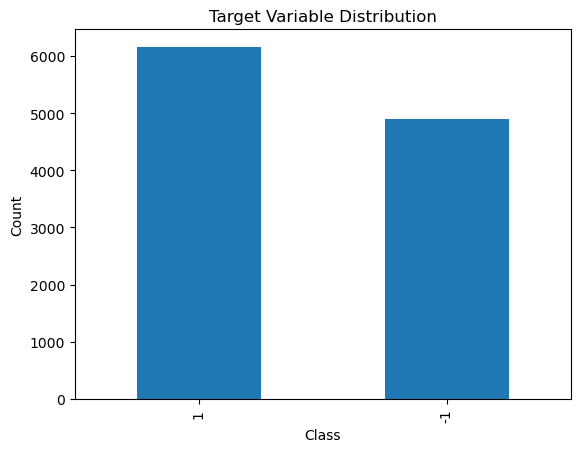

result
 1    55.694256
-1    44.305744
Name: proportion, dtype: float64

In [4]:
# ~55.7% of websites were legitimate
# ~ 44.3% of websites were phishing
# dataset of fairly balanced (no extreme skews)

plt.figure()
data['result'].value_counts().plot(kind='bar')
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Target Variable Distribution")
plt.show()

data['result'].value_counts(normalize=True) * 100

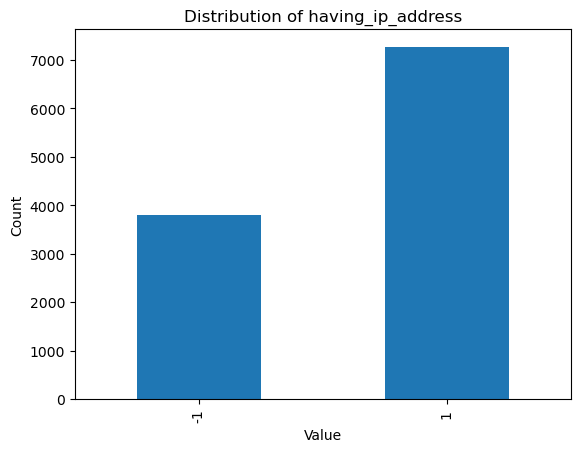

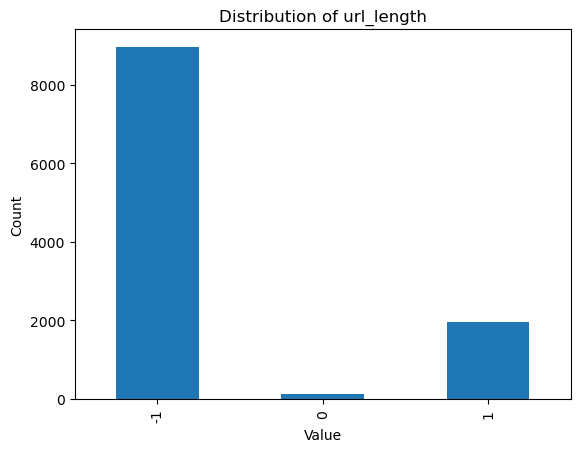

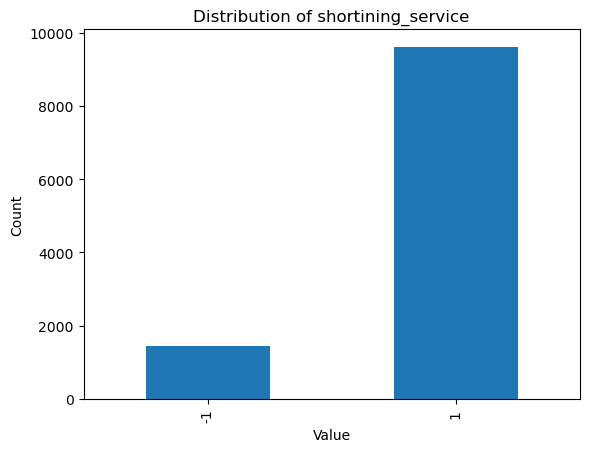

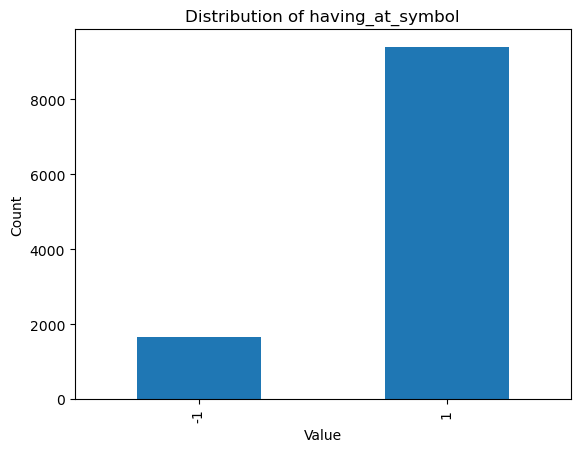

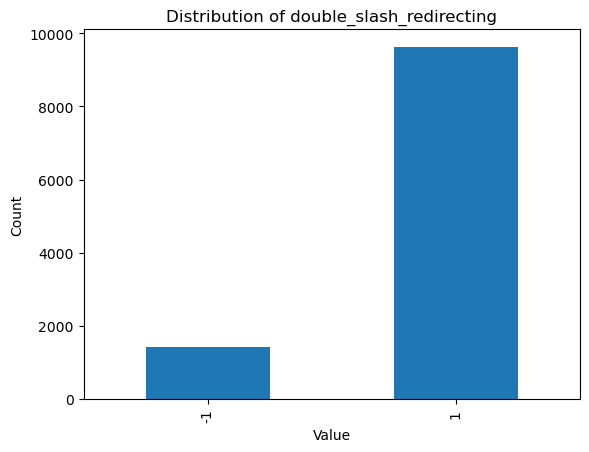

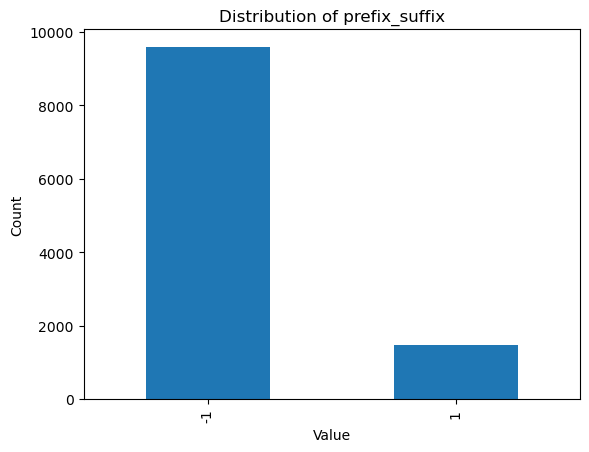

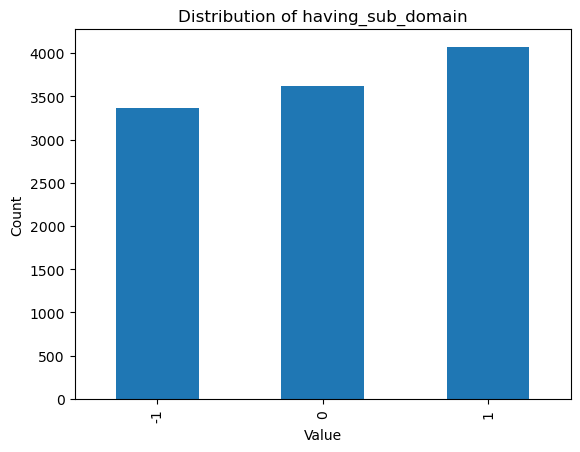

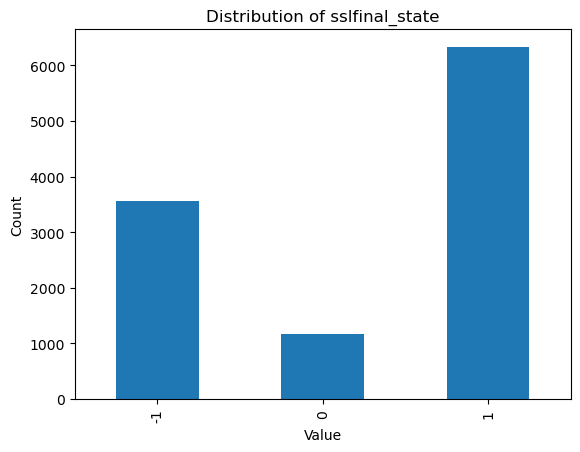

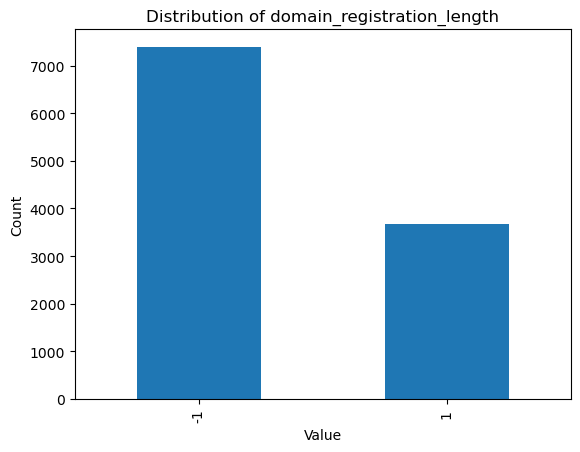

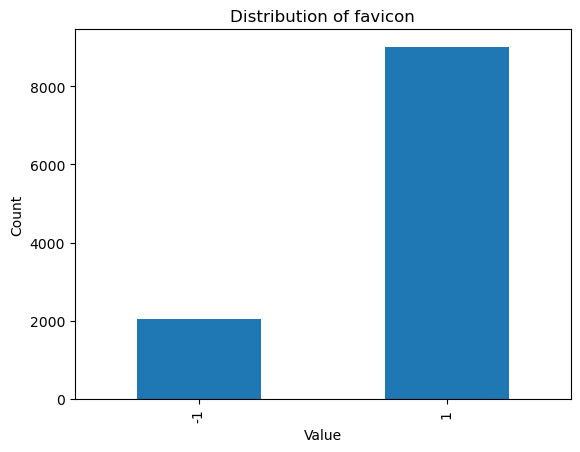

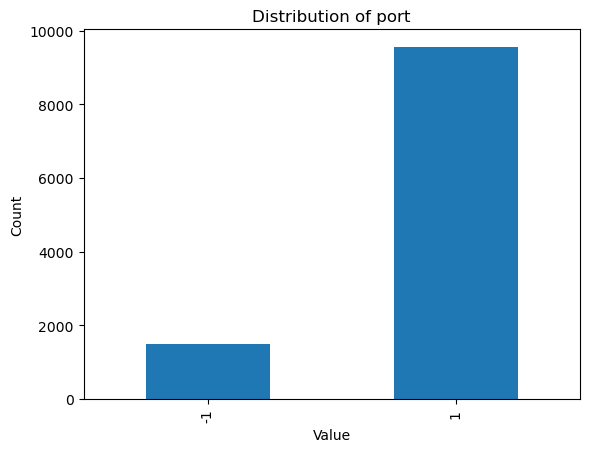

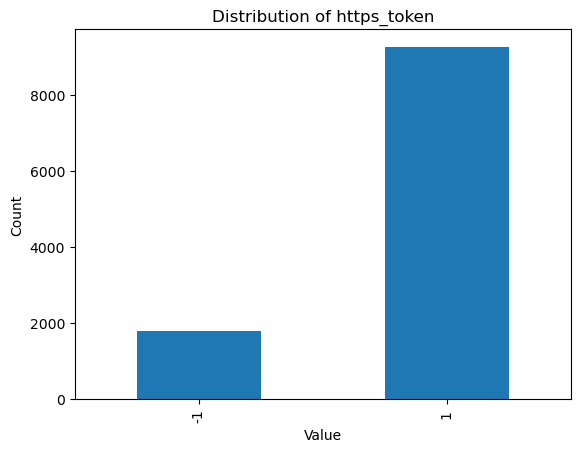

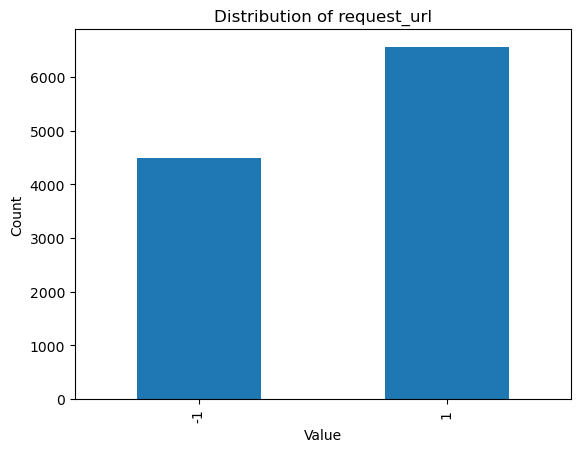

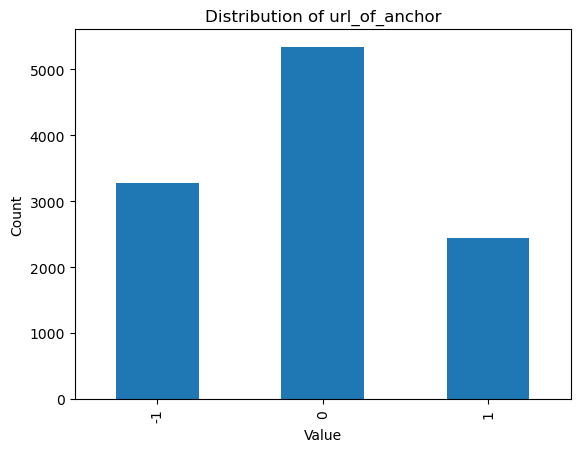

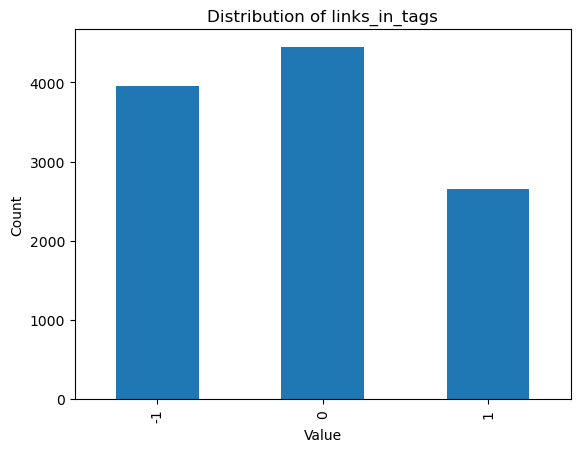

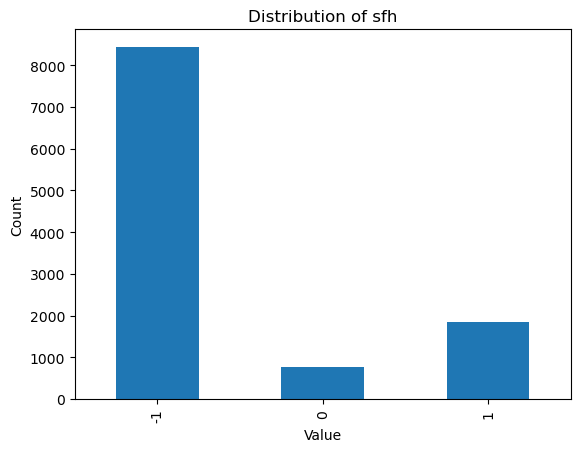

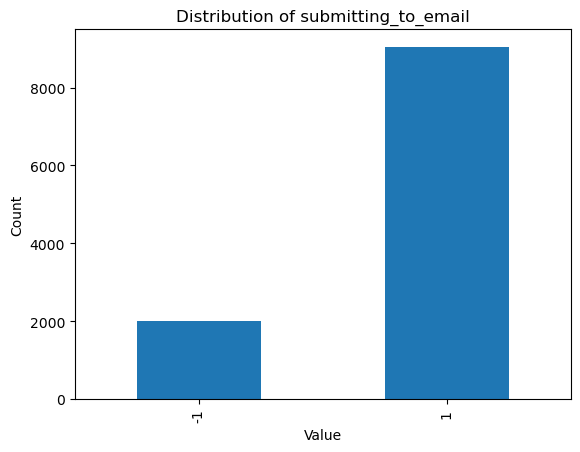

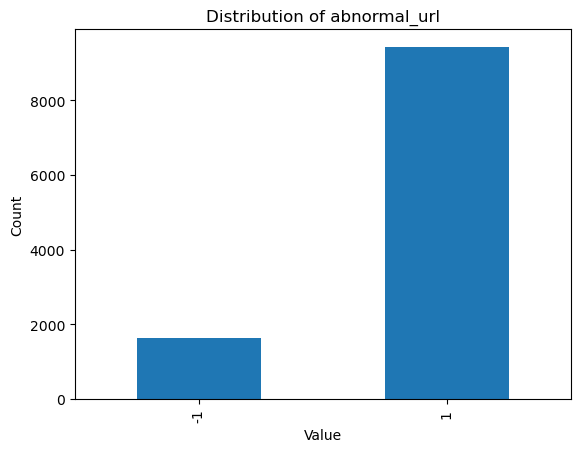

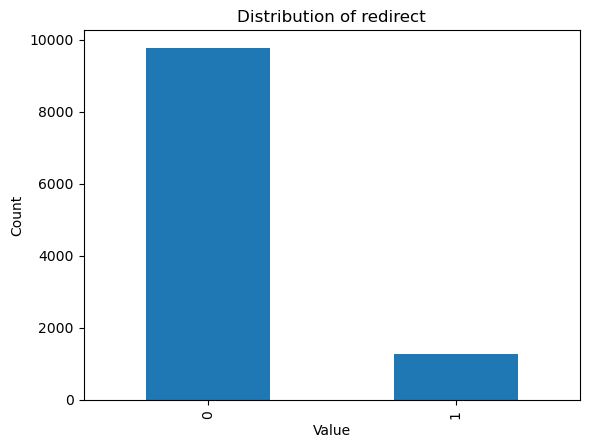

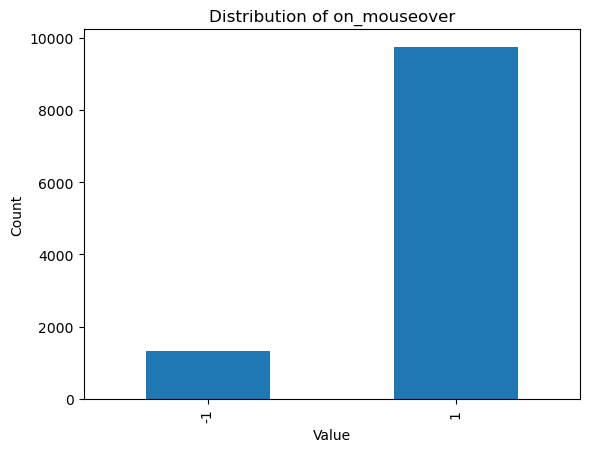

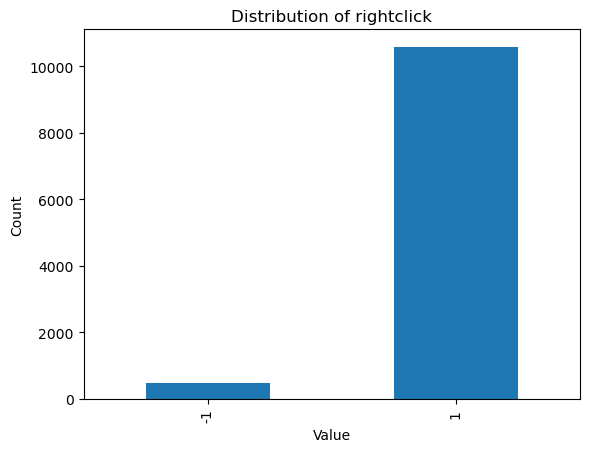

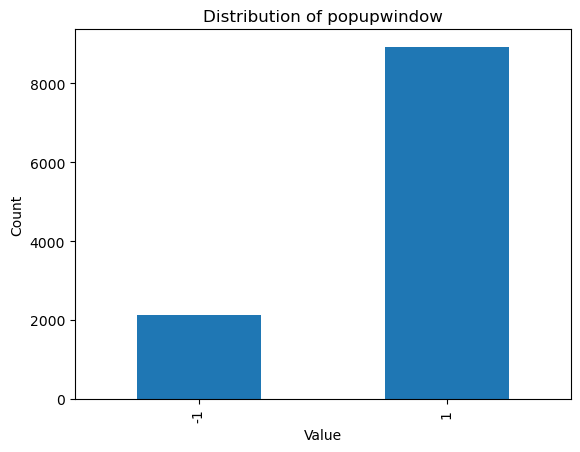

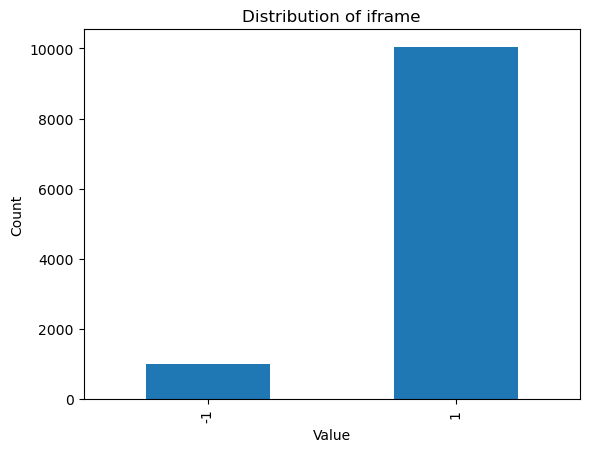

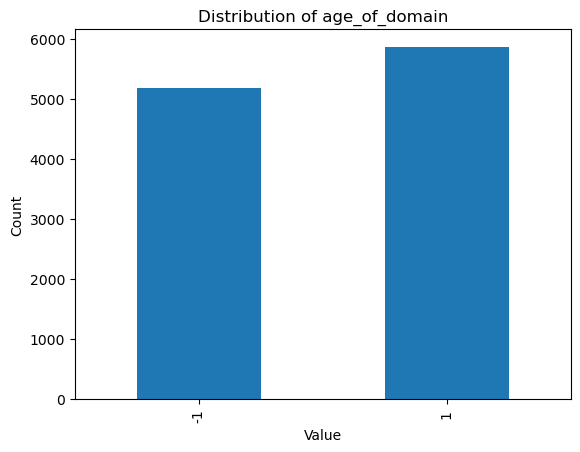

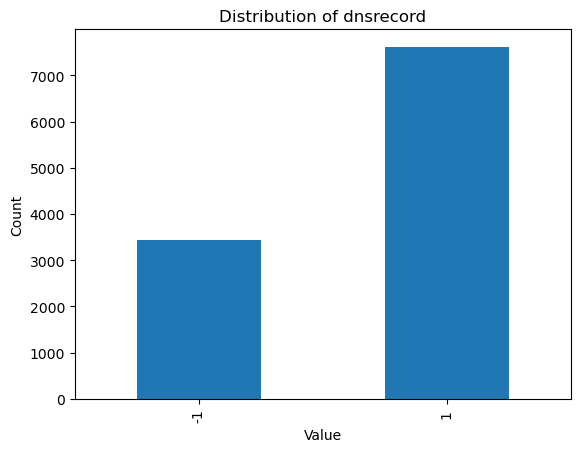

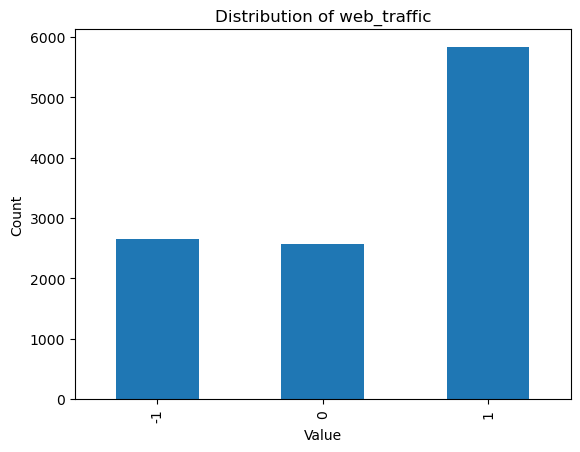

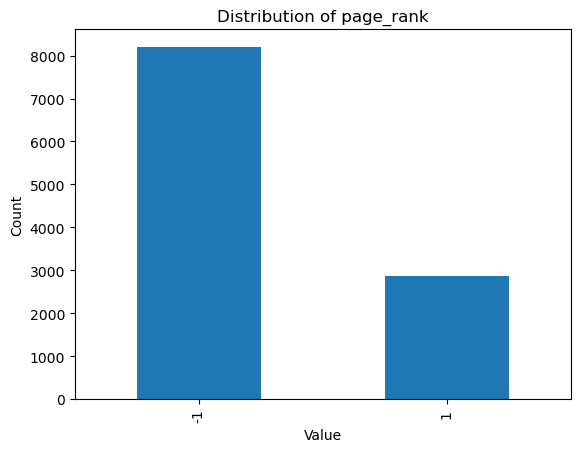

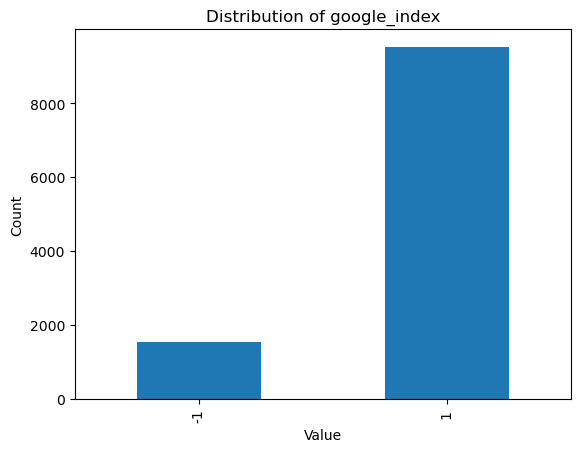

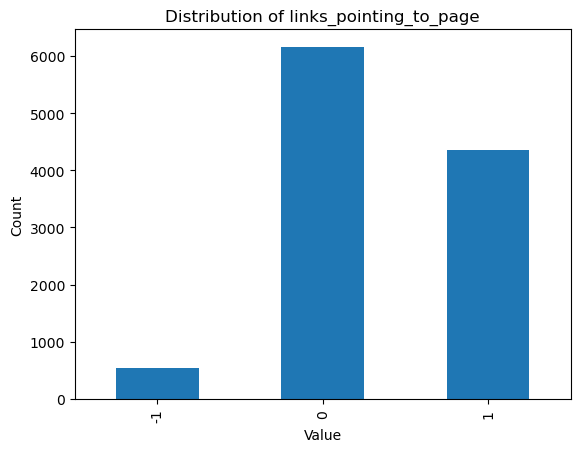

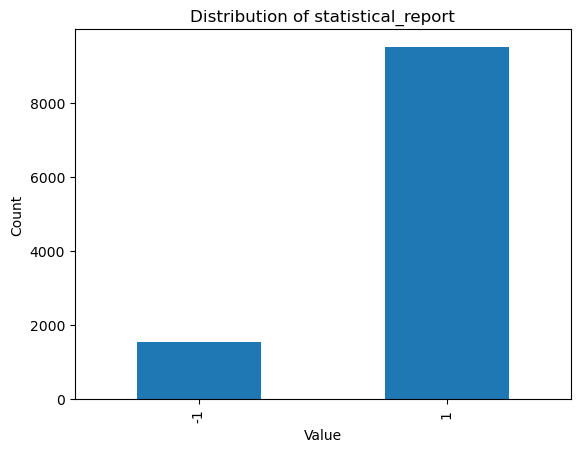

In [5]:
# Distribution of feature values

feature_cols = data.columns.drop('result')

for col in feature_cols:  
    plt.figure()
    data[col].value_counts().sort_index().plot(kind='bar')
    plt.title(f"Distribution of {col}")
    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.show()

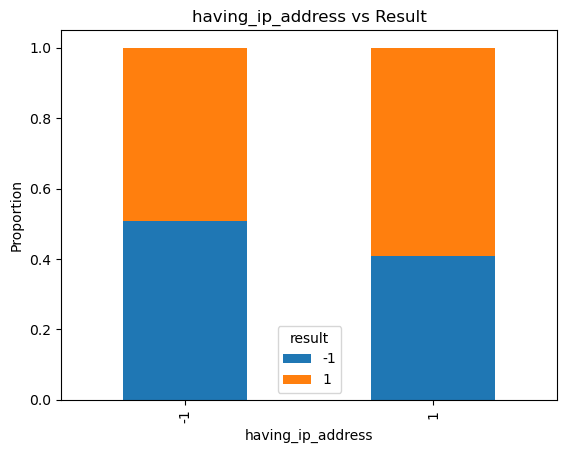

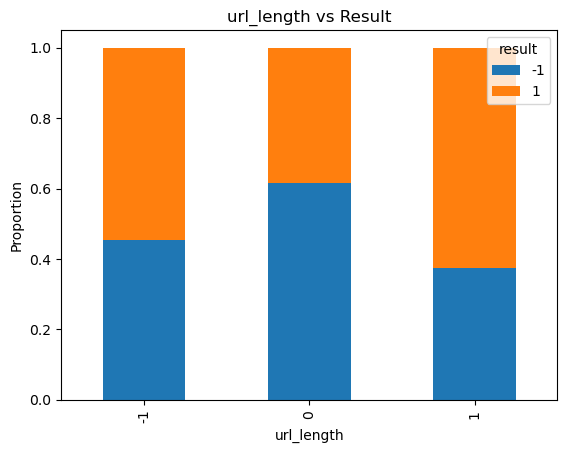

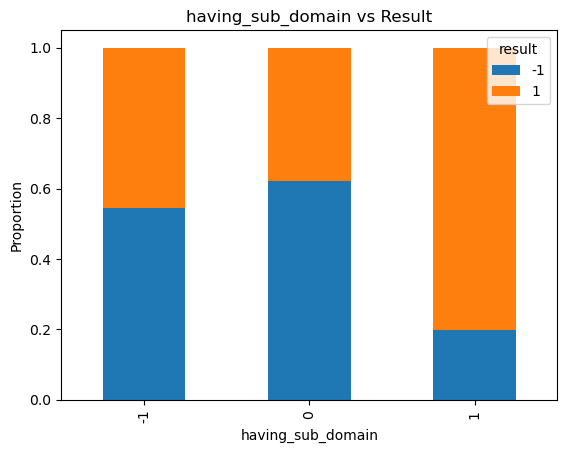

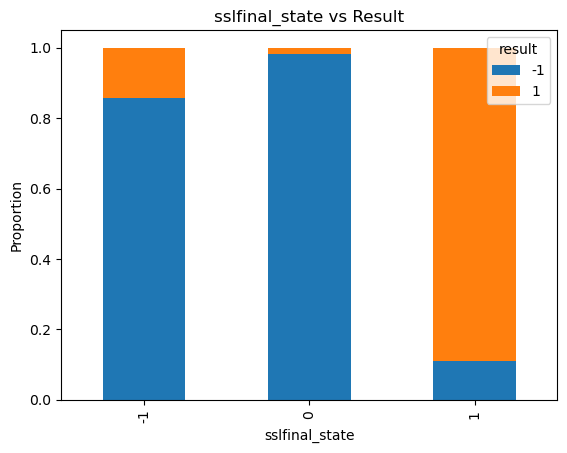

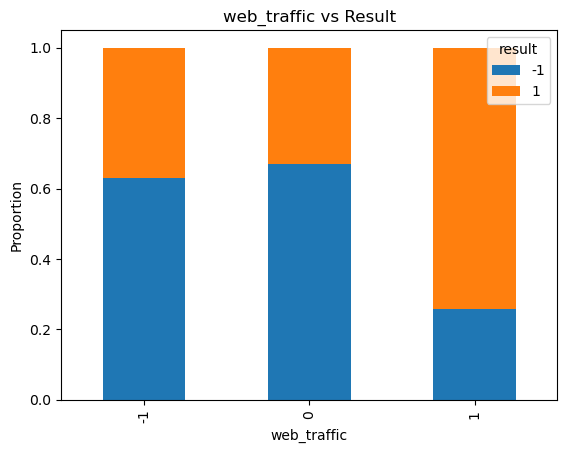

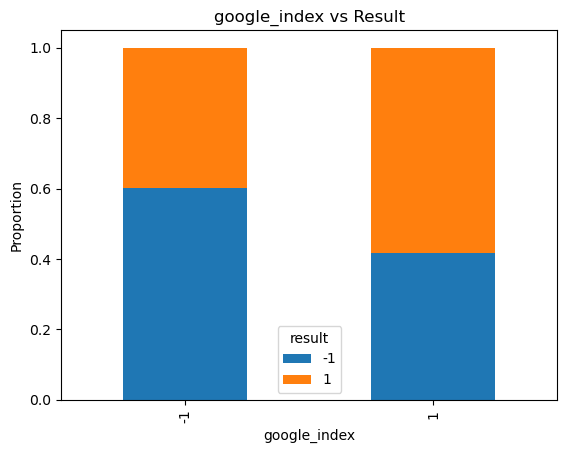

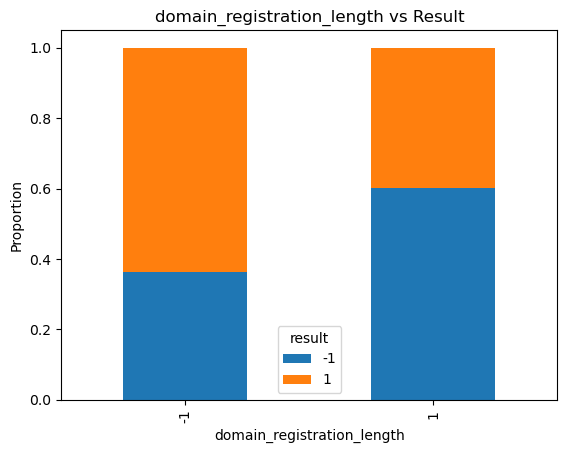

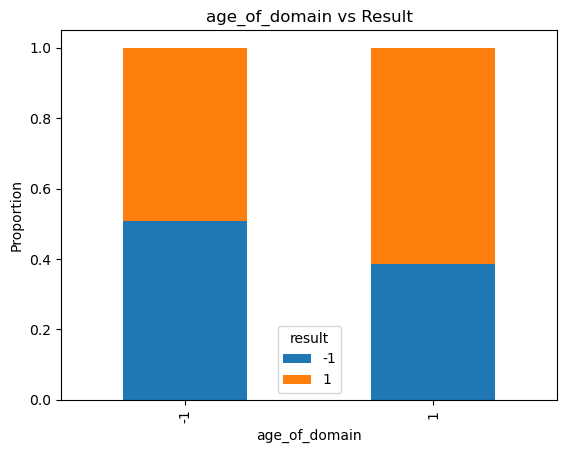

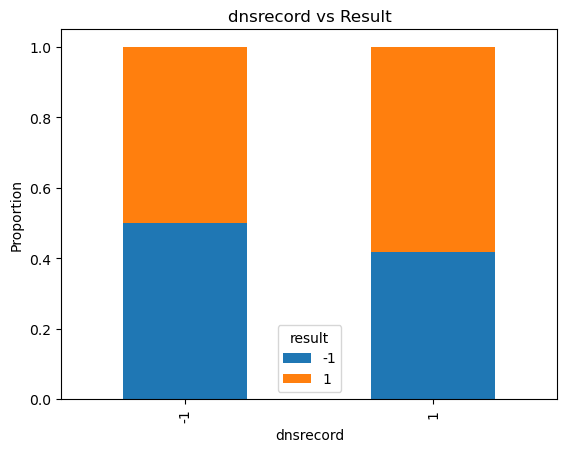

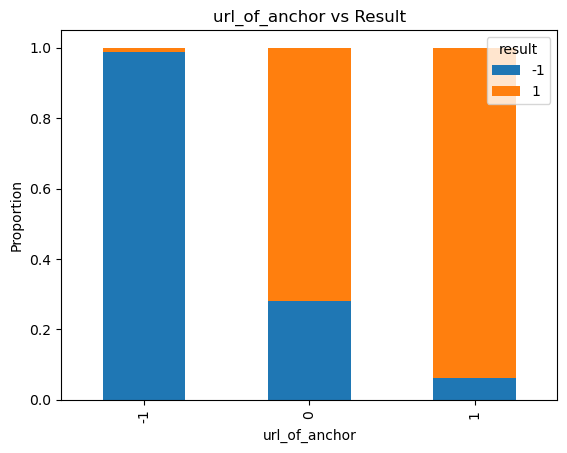

In [6]:
# sslfinal_state describes the security status of a website’s SSL/TLS certificate, i.e., whether the site uses HTTPS properly and safely.
# having_sub_domain, sslfinal_state, and web_traffic having value of 1, more likely to be legit website
# Proportionally stacked bar charts comparing feature values against the result label.

for col in ['having_ip_address', 'url_length', 'having_sub_domain', 'sslfinal_state', 'web_traffic', 'google_index', 'domain_registration_length', 'age_of_domain', 'dnsrecord', 'url_of_anchor']:
    crosstab = pd.crosstab(data[col], data['result'], normalize='index')
    crosstab.plot(kind='bar', stacked=True)
    plt.title(f"{col} vs Result")
    plt.ylabel("Proportion")
    plt.show()

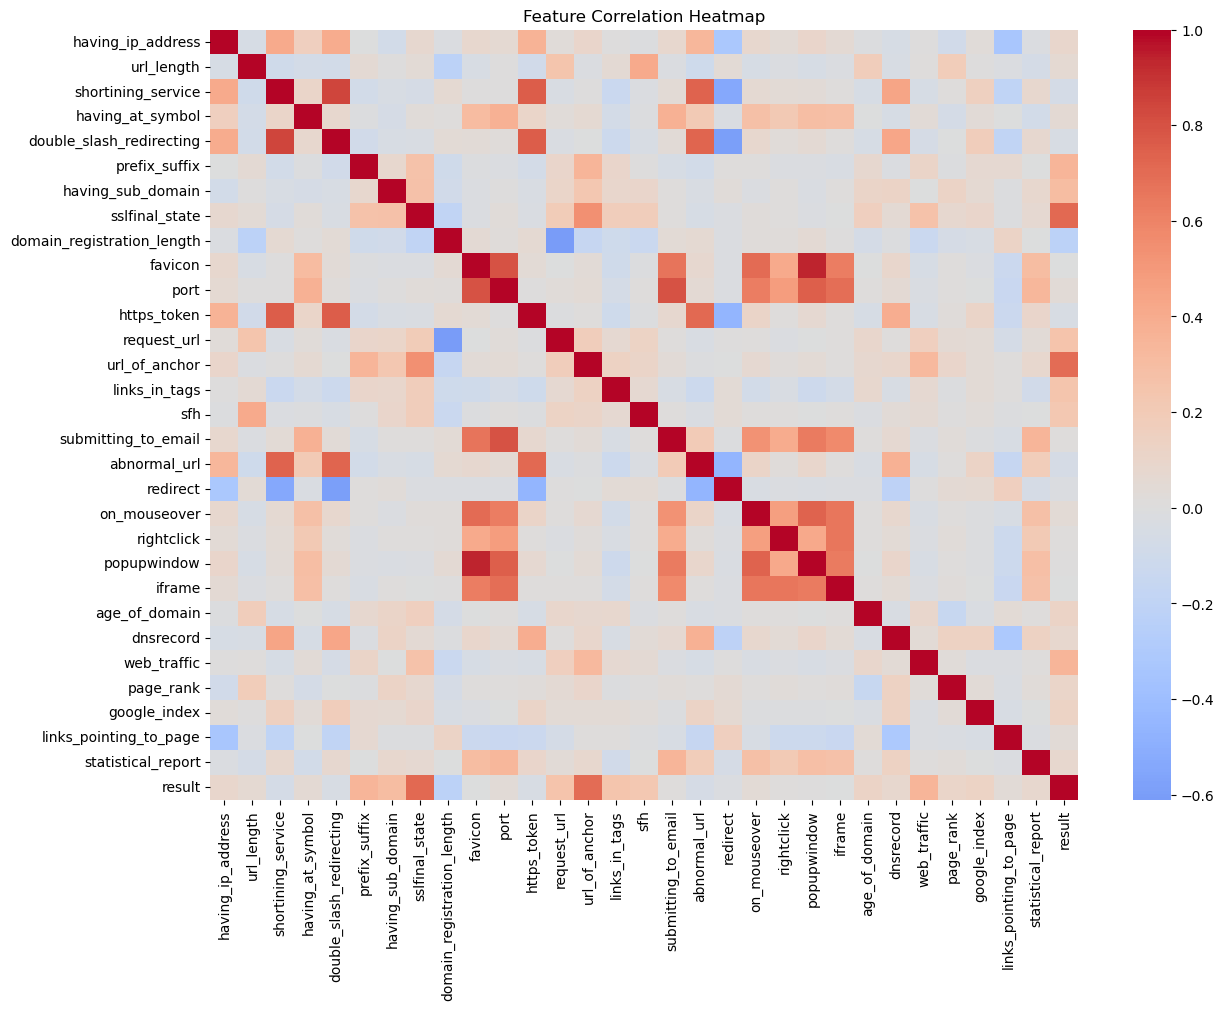

In [23]:
# look at last column to see which feature variables highly correlated with result (sslfinal_state, url_of_anchor)
# most features are weakly correlated (low multicollinearity), models won't suffer from redundant information


plt.figure(figsize=(14,10))
sns.heatmap(data.corr(), cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

# Possible Models

Tree-based models like random forest and XGBoost expected to achieve high classification performance. Data also exhibits nonlinear relationships
  
## - Random Forest
       - Handles categorical-style integer features naturally
       - Captures nonlinear interactions (very important for phishing)
       - Robust to noise and correlated features
       - No feature scaling required
## - XGBoost 
       - Gradient Boosting Tree-Based Model 
       - Learns subtle feature interactions
       - Often beats Random Forest in accuracy
       - Very strong on tabular data

-------------------------------------------------------------------------------------------------------
## - Logistic Regression
       - Simple and interpretable
       - Fast to train
       - Good baseline for comparison 